In [32]:
import pandas as pd

In [33]:
low_mass_satellite_df = pd.read_parquet ('../../data/low_mass_satellite_df_annuli_revised.parquet')

In [34]:
high_mass_satellite_df = pd.read_parquet ('../../data/high_mass_satellite_df_annuli_revised.parquet')

In [35]:
all_satellites_df = pd.concat([low_mass_satellite_df, high_mass_satellite_df], ignore_index=True)

In [36]:
all_satellites_df

,subID,bin_radii,avg_s_mass,avg_SFR,avg_gas_mass,quenching_vector,gas_mass,s_mass,BHMass,class,veldisp,global_SFRs,BH_cumQM,BH_cumRM,Mhalo,overdens,bulge,Bfld,BH_AGN
0,37.0,0.174505,8.905776,-0.052619,8.682093,0,0.022175,1.336990,0.003621,1,77.483803,2.468716,8.761890e+03,0.0,38878.035156,202.795135,-0.682291,0.694089,8.761890e+03
1,37.0,0.523516,8.636583,-0.643683,8.302815,0,0.022175,1.336990,0.003621,1,77.483803,2.468716,8.761890e+03,0.0,38878.035156,202.795135,-0.682291,0.694089,8.761890e+03
2,37.0,0.872526,8.421218,-1.414926,7.867777,0,0.022175,1.336990,0.003621,1,77.483803,2.468716,8.761890e+03,0.0,38878.035156,202.795135,-0.682291,0.694089,8.761890e+03
3,37.0,1.221537,8.243556,-1.699316,7.714798,0,0.022175,1.336990,0.003621,1,77.483803,2.468716,8.761890e+03,0.0,38878.035156,202.795135,-0.682291,0.694089,8.761890e+03
4,37.0,1.570547,8.094305,-1.657207,7.711024,0,0.022175,1.336990,0.003621,1,77.483803,2.468716,8.761890e+03,0.0,38878.035156,202.795135,-0.682291,0.694089,8.761890e+03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14501,476528.0,0.179965,9.485483,-2.459436,7.232764,1,0.000000,3.387989,0.010589,1,112.132950,0.018142,1.015537e+06,0.0,121.820320,6.780018,0.403195,0.133146,1.015537e+06
14502,476528.0,0.539895,9.195900,-2.790333,6.889097,1,0.000000,3.387989,0.010589,1,112.132950,0.018142,1.015537e+06,0.0,121.820320,6.780018,0.403195,0.133146,1.015537e+06
14503,476528.0,0.899825,8.818249,-3.192451,6.611662,1,0.000000,3.387989,0.010589,1,112.132950,0.018142,1.015537e+06,0.0,121.820320,6.780018,0.403195,0.133146,1.015537e+06
14504,476528.0,1.259755,8.497334,-3.498477,6.271559,1,0.000000,3.387989,0.010589,1,112.132950,0.018142,1.015537e+06,0.0,121.820320,6.780018,0.403195,0.133146,1.015537e+06


<Axes: >

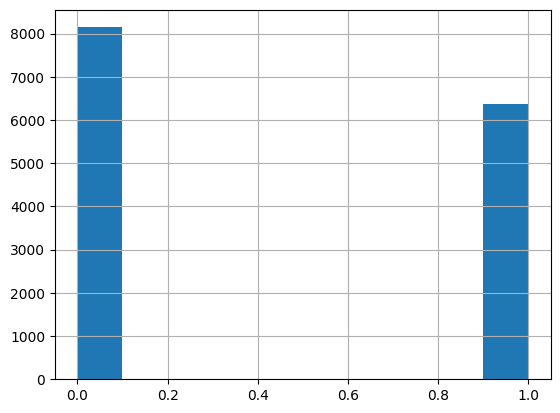

In [37]:
all_satellites_df['quenching_vector'].hist()

In [38]:
galaxy_class_counts = all_satellites_df.groupby("subID")["quenching_vector"].nunique()

# count galaxies with only one class vs. two classes
num_single_class_galaxies = (galaxy_class_counts == 1).sum()
num_two_class_galaxies = (galaxy_class_counts > 1).sum()

print(f"Number of galaxies with only one class: {num_single_class_galaxies}")
print(f"Number of galaxies with two classes: {num_two_class_galaxies}")

Number of galaxies with only one class: 843
Number of galaxies with two classes: 750


In [39]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import RobustScaler

# 'BHMass', 'BHCum_QM', 'Mhalo', 'overdens', and 'bulge' are the features wer are testing
all_satellites_df = all_satellites_df.drop(columns=["class", "BH_cumQM", "BH_cumRM", "global_SFRs", "avg_SFR","avg_gas_mass", "gas_mass", "Bfld", "veldisp", "BH_AGN","bulge"])
all_satellites_df.duplicated()

# X = low_mass_satellite_df.drop(['quenching_vector'], axis=1)
# y = low_mass_satellite_df['quenching_vector']

0        False
1        False
2        False
3        False
4        False
         ...  
14501    False
14502    False
14503    False
14504    False
14505    False
Length: 14506, dtype: bool

Fitting 5 folds for each of 10 candidates, totalling 50 fits
{'subsample': 0.7, 'scale_pos_weight': 1.0, 'n_estimators': 800, 'min_child_weight': 60, 'max_depth': 2, 'learning_rate': 0.003, 'lambda': 11, 'gamma': 1.2, 'colsample_bytree': 1.0, 'alpha': 11}


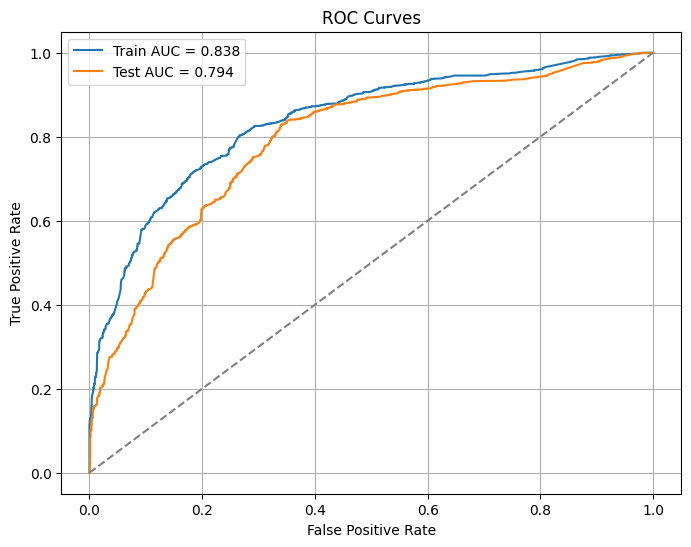

Gap (Train - Test AUC): 0.0442
Overfitting ratio (Train/Test AUC): 1.0557
Fitting 5 folds for each of 10 candidates, totalling 50 fits
{'subsample': 0.6, 'scale_pos_weight': 1.0, 'n_estimators': 800, 'min_child_weight': 120, 'max_depth': 2, 'learning_rate': 0.003, 'lambda': 9, 'gamma': 1.0, 'colsample_bytree': 1.0, 'alpha': 9}


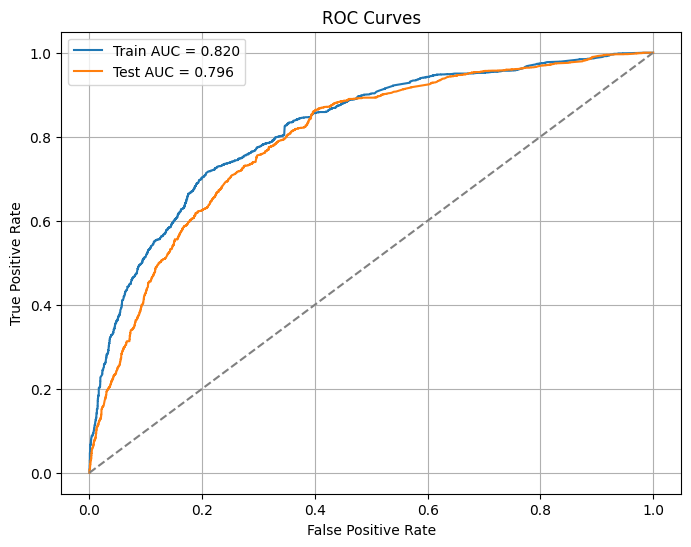

Gap (Train - Test AUC): 0.0242
Overfitting ratio (Train/Test AUC): 1.0304
Fitting 5 folds for each of 10 candidates, totalling 50 fits
{'subsample': 0.6, 'scale_pos_weight': 1.0, 'n_estimators': 700, 'min_child_weight': 120, 'max_depth': 2, 'learning_rate': 0.003, 'lambda': 10, 'gamma': 1.0, 'colsample_bytree': 1.0, 'alpha': 10}


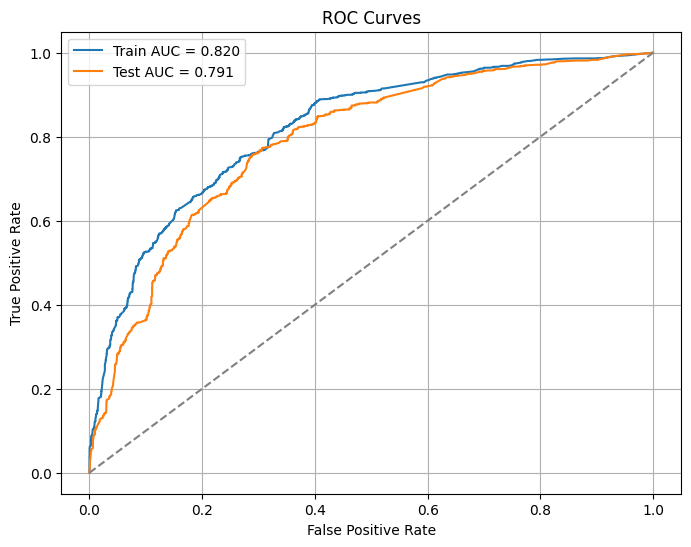

Gap (Train - Test AUC): 0.0295
Overfitting ratio (Train/Test AUC): 1.0373
Fitting 5 folds for each of 10 candidates, totalling 50 fits
{'subsample': 0.5, 'scale_pos_weight': 1.0, 'n_estimators': 600, 'min_child_weight': 60, 'max_depth': 2, 'learning_rate': 0.003, 'lambda': 10, 'gamma': 1.2, 'colsample_bytree': 1.0, 'alpha': 9}


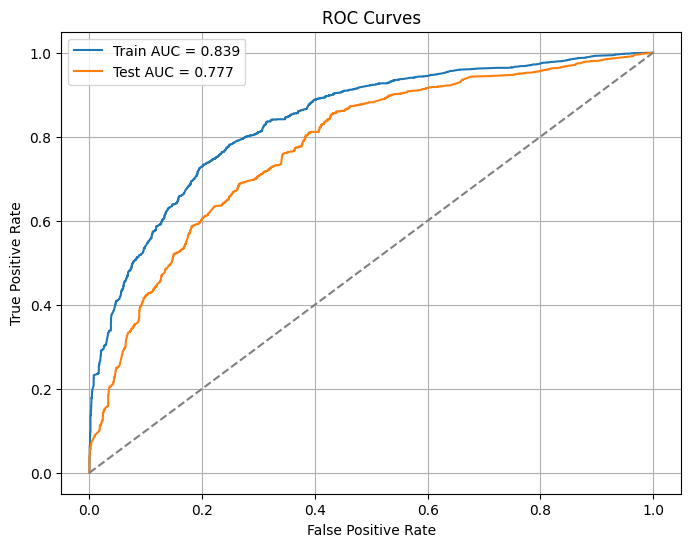

Gap (Train - Test AUC): 0.0626
Overfitting ratio (Train/Test AUC): 1.0806
Fitting 5 folds for each of 10 candidates, totalling 50 fits
{'subsample': 0.7, 'scale_pos_weight': 1.0, 'n_estimators': 700, 'min_child_weight': 80, 'max_depth': 2, 'learning_rate': 0.003, 'lambda': 11, 'gamma': 1.2, 'colsample_bytree': 1.0, 'alpha': 11}


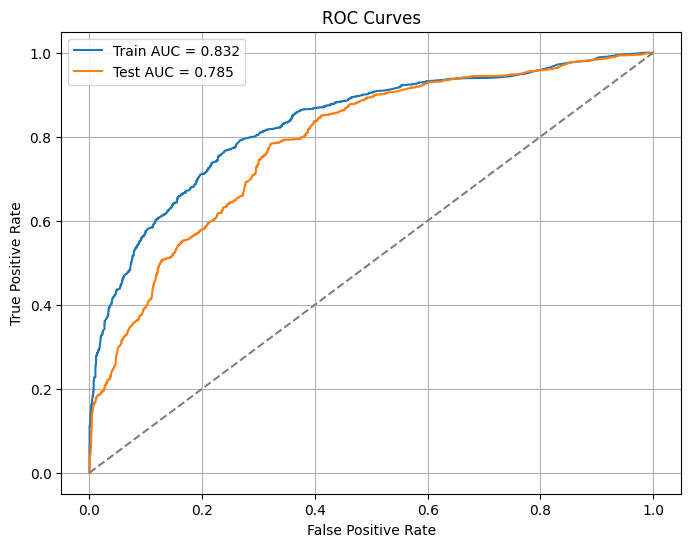

Gap (Train - Test AUC): 0.0467
Overfitting ratio (Train/Test AUC): 1.0595
Fitting 5 folds for each of 10 candidates, totalling 50 fits
{'subsample': 0.5, 'scale_pos_weight': 1.0, 'n_estimators': 800, 'min_child_weight': 120, 'max_depth': 2, 'learning_rate': 0.003, 'lambda': 9, 'gamma': 1.0, 'colsample_bytree': 1.0, 'alpha': 9}


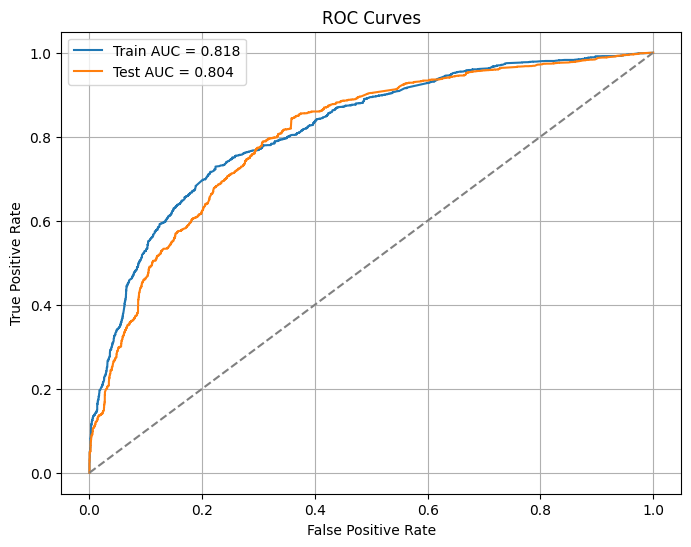

Gap (Train - Test AUC): 0.0139
Overfitting ratio (Train/Test AUC): 1.0172
Fitting 5 folds for each of 10 candidates, totalling 50 fits
{'subsample': 0.5, 'scale_pos_weight': 1.0, 'n_estimators': 600, 'min_child_weight': 60, 'max_depth': 2, 'learning_rate': 0.003, 'lambda': 11, 'gamma': 1.5, 'colsample_bytree': 1.0, 'alpha': 11}


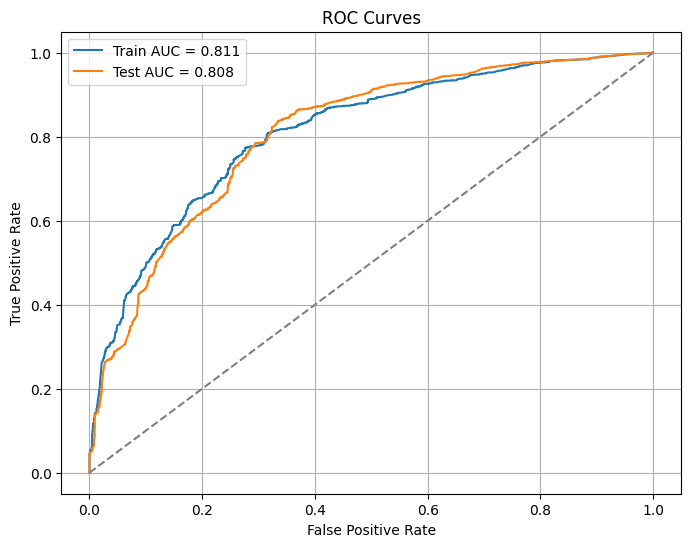

Gap (Train - Test AUC): 0.0037
Overfitting ratio (Train/Test AUC): 1.0045
Fitting 5 folds for each of 10 candidates, totalling 50 fits
{'subsample': 0.6, 'scale_pos_weight': 1.0, 'n_estimators': 800, 'min_child_weight': 100, 'max_depth': 2, 'learning_rate': 0.003, 'lambda': 10, 'gamma': 1.2, 'colsample_bytree': 1.0, 'alpha': 10}


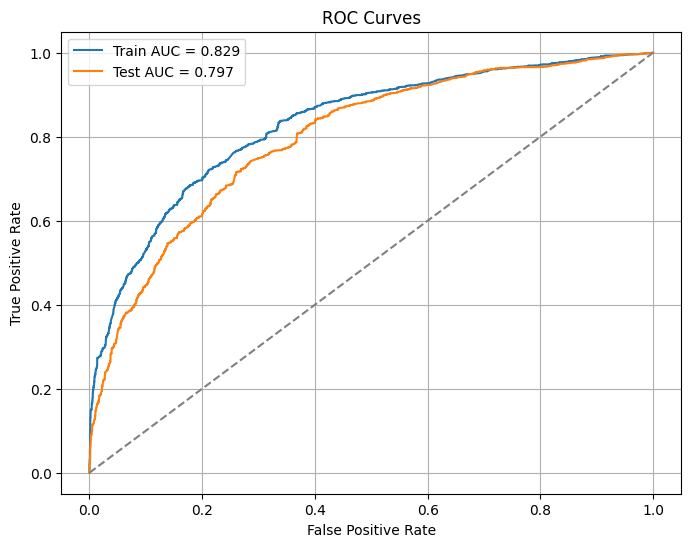

Gap (Train - Test AUC): 0.0322
Overfitting ratio (Train/Test AUC): 1.0404
Fitting 5 folds for each of 10 candidates, totalling 50 fits
{'subsample': 0.6, 'scale_pos_weight': 1.0, 'n_estimators': 700, 'min_child_weight': 60, 'max_depth': 2, 'learning_rate': 0.003, 'lambda': 10, 'gamma': 1.0, 'colsample_bytree': 1.0, 'alpha': 11}


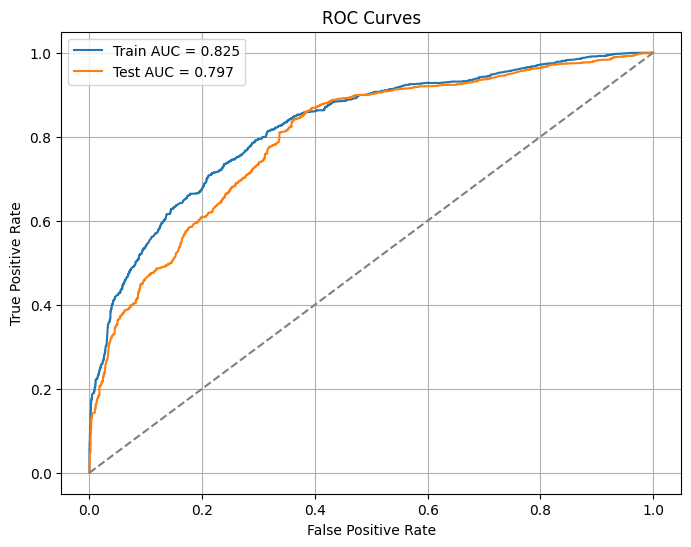

Gap (Train - Test AUC): 0.0278
Overfitting ratio (Train/Test AUC): 1.0349
Fitting 5 folds for each of 10 candidates, totalling 50 fits
{'subsample': 0.5, 'scale_pos_weight': 1.0, 'n_estimators': 700, 'min_child_weight': 120, 'max_depth': 2, 'learning_rate': 0.003, 'lambda': 10, 'gamma': 1.2, 'colsample_bytree': 1.0, 'alpha': 10}


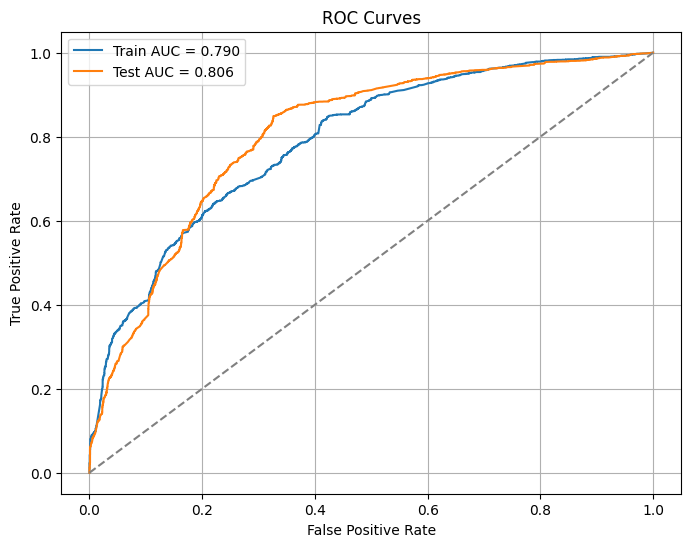

Gap (Train - Test AUC): -0.0156
Overfitting ratio (Train/Test AUC): 0.9807

Average AUC over 10 runs:
Train AUC: Mean = 0.8223, Std = 0.0136
Test AUC:  Mean = 0.7954, Std = 0.0091
Train F1: Mean = 0.7150, Std = 0.0210
Test F1:  Mean = 0.7003, Std = 0.0088

Gap stats: Mean = 0.0269, Std = 0.0213, Min = -0.0156, Max = 0.0626
Overfitting ratio stats: Mean = 1.0341, Std = 0.0271


In [40]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import f1_score

# splitting galaxies into test/train based on subID
unique_galaxies = np.unique(all_satellites_df['subID'])

train_aucs = []
test_aucs = []
feature_importances_list = []
feature_names = None
train_f1s = []
test_f1s = []


for seed in range(10):
    train_galaxies, test_galaxies = train_test_split(unique_galaxies, test_size=0.5, random_state=seed)

    train_data = all_satellites_df[all_satellites_df['subID'].isin(train_galaxies)]
    test_data = all_satellites_df[all_satellites_df['subID'].isin(test_galaxies)]

    X_train, y_train = train_data.drop(columns=['quenching_vector', 'subID']), train_data['quenching_vector']
    X_test, y_test = test_data.drop(columns=['quenching_vector', 'subID']), test_data['quenching_vector']

    if feature_names is None:
        feature_names = X_train.columns.tolist()
    # scaling
    scaler = RobustScaler()
    X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
    X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

    xgb_clf = xgb.XGBClassifier(random_state=seed, objective='binary:logistic')

    param_grid_xgb = {
    'n_estimators': [600, 700, 800],
    'max_depth': [2],
    'learning_rate': [0.003],
    'subsample': [0.5, 0.6, 0.7],
    'colsample_bytree': [1.0],
    'min_child_weight': [60, 80, 100, 120],
    'gamma': [1.0, 1.2, 1.5],
    'lambda': [9, 10, 11],
    'alpha': [9, 10, 11],
    'scale_pos_weight': [1.0]
    }

    random_search_xgb = RandomizedSearchCV(
    estimator=xgb_clf,
    param_distributions=param_grid_xgb,
    n_iter=10,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1, 
    random_state=seed,
    verbose=2,
    )

    random_search_xgb.fit(X_train_scaled, y_train)

    best_xgb = random_search_xgb.best_estimator_
    print(random_search_xgb.best_params_)

    y_train_prob = best_xgb.predict_proba(X_train_scaled)[:, 1]
    y_test_prob = best_xgb.predict_proba(X_test_scaled)[:, 1]

    fpr_train, tpr_train, _ = roc_curve(y_train, y_train_prob)
    fpr_test, tpr_test, _ = roc_curve(y_test, y_test_prob)

    # ROC curves
    plt.figure(figsize=(8,6))
    plt.plot(fpr_train, tpr_train, label=f'Train AUC = {roc_auc_score(y_train, y_train_prob):.3f}')
    plt.plot(fpr_test, tpr_test, label=f'Test AUC = {roc_auc_score(y_test, y_test_prob):.3f}')
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    # aucs and feature importance
    train_auc = roc_auc_score(y_train, y_train_prob)
    test_auc = roc_auc_score(y_test, y_test_prob)
    feature_importances_list.append(best_xgb.feature_importances_)
    
    train_aucs.append(train_auc)
    test_aucs.append(test_auc)
    gap = train_auc - test_auc
    print(f"Gap (Train - Test AUC): {gap:.4f}")
    print(f"Overfitting ratio (Train/Test AUC): {train_auc / test_auc:.4f}")


    y_train_pred = best_xgb.predict(X_train_scaled)
    y_test_pred = best_xgb.predict(X_test_scaled)

    # f1 scores
    train_f1 = f1_score(y_train, y_train_pred)
    test_f1 = f1_score(y_test, y_test_pred)

    train_f1s.append(train_f1)
    test_f1s.append(test_f1)
    
print("\nAverage AUC over 10 runs:")
print(f"Train AUC: Mean = {np.mean(train_aucs):.4f}, Std = {np.std(train_aucs):.4f}")
print(f"Test AUC:  Mean = {np.mean(test_aucs):.4f}, Std = {np.std(test_aucs):.4f}")
print(f"Train F1: Mean = {np.mean(train_f1s):.4f}, Std = {np.std(train_f1s):.4f}")
print(f"Test F1:  Mean = {np.mean(test_f1s):.4f}, Std = {np.std(test_f1s):.4f}")
gaps = [train - test for train, test in zip(train_aucs, test_aucs)]
overfit_ratios = [train / test for train, test in zip(train_aucs, test_aucs)]
print(f"\nGap stats: Mean = {np.mean(gaps):.4f}, Std = {np.std(gaps):.4f}, Min = {np.min(gaps):.4f}, Max = {np.max(gaps):.4f}")
print(f"Overfitting ratio stats: Mean = {np.mean(overfit_ratios):.4f}, Std = {np.std(overfit_ratios):.4f}")


=== Average Feature Importances ===
      Feature  Mean Importance   Std Dev
4       Mhalo         0.339505  0.027058
3      BHMass         0.255830  0.032910
1  avg_s_mass         0.137539  0.017388
2      s_mass         0.109480  0.043657
5    overdens         0.089012  0.033274
0   bin_radii         0.068633  0.012739


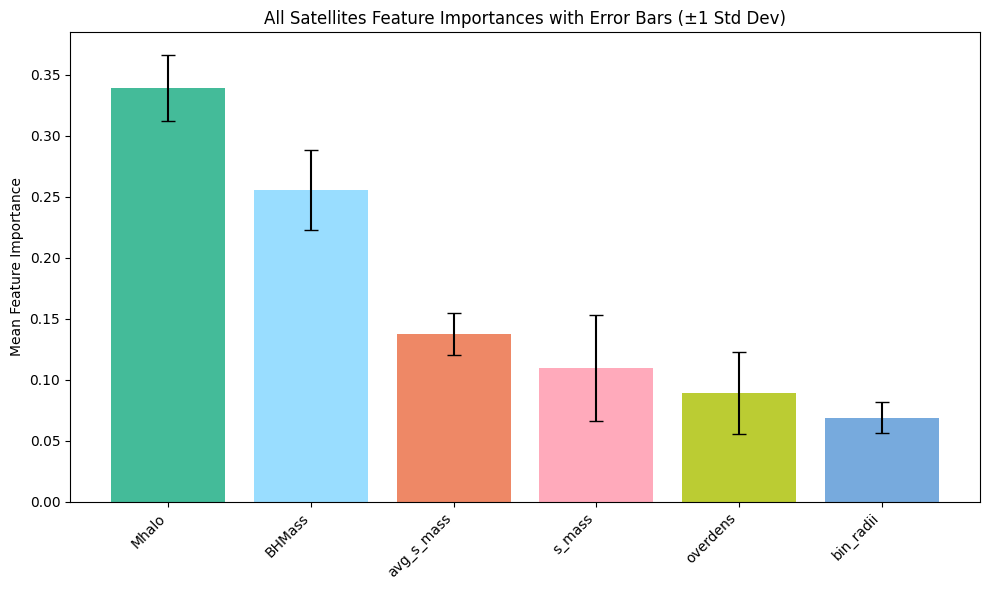

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
feature_colors = {
    'bin_radii': '#77AADD',
    'avg_s_mass': '#EE8866',
    's_mass': '#FFAABB',
    'BHMass': '#99DDFF',
    'Mhalo': '#44BB99',
    'overdens': '#BBCC33',
    'bulge': '#AAAA00',
    'BH_AGN': '#DDDDDD',
}

# importances + stds across 10 runs
importances_array = np.array(feature_importances_list)
importance_means = np.mean(importances_array, axis=0)
importance_stds = np.std(importances_array, axis=0)

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Mean Importance': importance_means,
    'Std Dev': importance_stds
}).sort_values(by='Mean Importance', ascending=False)

print("\n=== Average Feature Importances ===")
print(importance_df)

colors = [feature_colors[feat] for feat in importance_df['Feature']]
# Plot
plt.figure(figsize=(10, 6))
plt.bar(importance_df['Feature'], importance_df['Mean Importance'], yerr=importance_df['Std Dev'], capsize=5, color=colors)
plt.xticks(rotation=45, ha='right')
plt.ylabel("Mean Feature Importance")
plt.title("All Satellites Feature Importances with Error Bars (±1 Std Dev)")
plt.tight_layout()
plt.show()

In [42]:
# from sklearn.metrics import f1_score
# y_train_pred = best_rf.predict(X_train_scaled)
# y_test_pred = best_rf.predict(X_test_scaled)

# # f1 scores
# train_f1 = f1_score(y_train, y_train_pred)
# test_f1 = f1_score(y_test, y_test_pred)

# print(f"Train F1 Score: {train_f1:.3f}")
# print(f"Test F1 Score: {test_f1:.3f}")

In [43]:
import os
# Define your directory and file name
directory = 'xg_classification_outputs'
filename = 'all_satellites_xg_quenching.csv'
filepath = os.path.join(directory, filename)

# Create the directory if it doesn't exist
os.makedirs(directory, exist_ok=True)

# Save the DataFrame
importance_df.to_csv(filepath, index=False)

print(f'DataFrame saved to {filepath}')

DataFrame saved to xg_classification_outputs\all_satellites_xg_quenching.csv


In [44]:
train_mean = round(np.mean(train_aucs), 2)
test_mean = round(np.mean(test_aucs), 2)
print(train_mean)
df = pd.DataFrame({
    'Train AUC': [train_mean],
    'Test AUC': [test_mean]
})

print(df)
import os
# Define your directory and file name
directory = 'xg_classification_outputs'
filename = 'all_satellites_xg_quenching_auc.csv'
filepath = os.path.join(directory, filename)

# Create the directory if it doesn't exist
os.makedirs(directory, exist_ok=True)

# Save the DataFrame
df.to_csv(filepath, index=False)

print(f'DataFrame saved to {filepath}')

0.82
   Train AUC  Test AUC
0       0.82       0.8
DataFrame saved to xg_classification_outputs\all_satellites_xg_quenching_auc.csv
